In [2]:
from dotenv import load_dotenv
from openai.types.responses import ResponseTextDeltaEvent
from typing import Dict
import os
import asyncio
from agents import Agent, Runner, trace, function_tool, OpenAIChatCompletionsModel, input_guardrail, GuardrailFunctionOutput
from openai import AsyncOpenAI

In [3]:
load_dotenv(override=True)

True

In [4]:
google_api_key = os.getenv('GOOGLE_API_KEY')
groq_api_key = os.getenv('GROQ_API_KEY')
telegram_token=os.getenv('TELEGRAM')
chat_id=os.getenv('TELEGRAM_CHAT_ID')


if google_api_key:
    print(f"Google API Key exists and begins {google_api_key[:2]}")
else:
    print("Google API Key not set (and this is optional)")


if groq_api_key:
    print(f"Groq API Key exists and begins {groq_api_key[:4]}")
else:
    print("Groq token not set (and this is optional)")



if telegram_token:
    print(f"telegram token exists and begins {telegram_token[:2]}")
else:
    print("telegram token not set (and this is optional)")



if chat_id:
    print(f"telegram chat_id exists and begins {chat_id[:2]}")
else:
    print("telegram chat_id not set (and this is optional)")

Google API Key exists and begins AI
Groq API Key exists and begins gsk_
telegram token exists and begins 81
telegram chat_id exists and begins 60


**Agent that gives good search queries**

In [5]:
GEMINI_BASE_URL = "https://generativelanguage.googleapis.com/v1beta/openai/"
GROQ_BASE_URL = "https://api.groq.com/openai/v1"

In [70]:
instructions1='''you are a agent who is good at generating smart queries,keywords to search given a topic and platform on which to search (platform is optional). 
Give  most efficient query inform of keywords in JSON format with the text to query in 'query' key. like {'query':....,}. no explaination. 
Provide 3 different queries. one is most basic, second is little modified, and 3rd should be added more and more intelligence by you.
Use your intelligence to understand what user is going to search.'''
groq_client = AsyncOpenAI(base_url=GROQ_BASE_URL, api_key=groq_api_key)


llama3_3_model = OpenAIChatCompletionsModel(model="llama-3.3-70b-versatile", openai_client=groq_client)
query_agent =  Agent(name="query_creator_Agent", instructions=instructions1, model=llama3_3_model)

# agent1.as_tool(tool_name="Query Agent", tool_description="Get most efficient query to search for something.")

In [71]:
result = Runner.run_streamed(query_agent, input="Operation Sindur India mission details")
async for event in result.stream_events():
    if event.type == "raw_response_event" and isinstance(event.data, ResponseTextDeltaEvent):
        print(event.data.delta, end="", flush=True)

{'query': 'Operation Sindur India mission details'}
{'query': 'Operation Sindur mission objectives India'}
{'query': 'Operation Sindur India mission details objectives success stories Indian military operations'}

**Tool to search on arxiv**

In [8]:
import arxiv


@function_tool
def search_on_arxiv(query):
    """
This Tool is used to search for some research paper on arxiv. It'll provide following info about papers:
Title
Authors
PDF url
Publication year
Categories
Abstract

Note that this is arxiv so it may or may not give good papers so results can be verified rigorously and use tool wisely.
    """
    num_results=30
    search = arxiv.Search(
        query=query,
        max_results=num_results,
        sort_by=arxiv.SortCriterion.Relevance #SubmittedDate

    )
    papers=[]
    for result in search():
        content={}
        content["Title:"]=result.title
        content["Authors:"]= [a.name for a in result.authors]
        content["PDF:"]= result.pdf_url
        content["Published:"]= result.published
        content["Categories:"]= result.categories
        content["Abstract:"]=result.summary
        papers.append(content)

    
    return  papers


**Search using duck duck go**

In [25]:
!pip install ddgs pandas

   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
    --------------------------------------- 0.3/11.0 MB ? eta -:--:--
    --------------------------------------- 0.3/11.0 MB ? eta -:--:--
    --------------------------------------- 0.3/11.0 MB ? eta -:--:--
    --------------------------------------- 0.3/11.0 MB ? eta -:--:--
    --------------------------------------- 0.3/11.0 MB ? eta -:--:--
    --------------------------------------- 0.3/11.0 MB ? eta -:--:--
    --------------------------------------- 0.3/11.0 MB ? eta -:--:--
    --------------------------------------- 0.3/11.0 MB ? eta -:--:--
   - ---------------

In [63]:
import time
import random
from ddgs import DDGS 
import pandas as pd

class WebSearch:
    # def polite_delay(self,min_delay=1.2, max_delay=2.5):
    #     time.sleep(random.uniform(min_delay, max_delay))
    def polite_delay(self, *delay):
        time.sleep(random.uniform(*delay))

    def safe_duckduckgo_call(self,search_fn, *args, retries=3, delay=(1.5, 3.5), **kwargs):
        for attempt in range(retries):
            try:
                self.polite_delay(*delay)
                return search_fn(*args, **kwargs)
            except Exception as e:
                print(f"Attempt {attempt+1} failed: {e}")
                time.sleep((attempt + 1) * 2)
        print("⚠️ Failed after multiple attempts.")
        return []


    # --- SEARCH FUNCTIONS ---

    def search_videos(self,search_query, dataframe=False):
        results = self.safe_duckduckgo_call(
            DDGS().videos,
            # keywords=search_query,
            query=search_query,
            region="wt-wt",
            safesearch="on",
            timelimit="3m",
            resolution="high",
            duration="medium",
            max_results=2
        )
        if dataframe:
            results = pd.DataFrame(results)
        return results


    def search_text(self,search_query, dataframe=False):
        '''[
                {"title":'',   "body":'',    "href":''},
                ...
        ]'''
        results = self.safe_duckduckgo_call(
            DDGS().text,
            # keywords=search_query,
            query=search_query,
            region='wt-wt',
            safesearch='off',
            timelimit='7d',
            max_results=2
        )
        if dataframe:
            results = pd.DataFrame(results)
        return results


    def search_images(self,search_query, dataframe=False):
        results = self.safe_duckduckgo_call(
            DDGS().images,
            # keywords=search_query,
            query=search_query,
            region="wt-wt",
            safesearch="off",
            size=None,
            color="Monochrome",
            type_image=None,
            layout=None,
            license_image=None,
            max_results=2
        )
        if dataframe:
            results = pd.DataFrame(results)
        return results



@function_tool
def web_search(query):
    """
Search on web using duck-duck go
query what you want in this functions.
"""
    bot=WebSearch()
    return bot.search_text(search_query=query)



@function_tool
def web_image_search(query):
    """
Search images on web using duck-duck go
query what you want in this functions.
"""
    bot=WebSearch()
    return bot.search_images(search_query=query)

In [62]:
# DDGS().text(keyword='apple')
web_search('apple yummy')

[{'title': '43 Applesyummy ideas | yummy food, delicious desserts, apple...',
  'href': 'https://www.pinterest.com/abterry99/apples-yummy/',
  'body': 'See more ideas about yummy food, delicious desserts, apple recipes.apples with nuts and caramel sauce on a white plate next to some green apples.'},
 {'title': 'I Think The Apple Looks So Yummy and Tasty | TikTok',
  'href': 'https://www.tiktok.com/discover/i-think-the-apple-looks-so-yummy-and-tasty',
  'body': 'Perfect for school snacks and healthy eating. yummyapple, apples that look so yummy, delicious apple recipes, healthy apple snacks, tasty apple ideas Last updated 2025-03-03.'}]

**Telegram notifier**

In [25]:
import requests

@function_tool
def Notify(message):
    """ Use this tool to send notification to your boss using a text messsage with Telegram.
    """
    bot_token = telegram_token

    url = f"https://api.telegram.org/bot{bot_token}/sendMessage"
    data = {"chat_id": chat_id, "text": message}

    response = requests.post(url, data=data)
    return {'Notified':response.json()['ok']}

In [24]:
Notify("Hit the road jack and don't you come back!")

{'Notified': True}

**Calculator**

In [11]:
@function_tool
def Calculate(expression):
    """A calculator! use this tool to calculate some big mathematical expression. just give that in form of tool"""
    return {"results":eval(expression)}

**execute code**

In [13]:
import io
import contextlib
import traceback
import json

@function_tool
def run_code(code_str: str) -> dict:
    
    """
    Executes a given Python code string and captures its output.

    This function is designed for use by AI agents or other automated tools
    that need to evaluate dynamically generated Python code. It runs the code
    in an isolated scope, captures anything printed to standard output, and
    returns the results in a structured JSON-like dictionary.

    Parameters:
    -----------
    code_str : str
        A string containing valid Python code. The code can include print 
        statements or any basic Python logic.

    Returns:
    --------
    dict
        A dictionary with the following keys:
        - 'success': bool indicating whether the code ran without errors.
        - 'output': str containing all printed output from the code.
        - 'error': str containing the full traceback if an exception occurred.

    Example:
    --------
    >>> run_user_code("print('Hello, world!')")
    {
        "success": True,
        "output": "Hello, world!\\n",
        "error": ""
    }

    Notes:
    ------
    - This function does NOT sandbox the code for security. It should not be 
      used to run untrusted or user-generated code in production environments.
    - All `print()` outputs are captured and returned in the 'output' field.
    - Exceptions are caught and included in the 'error' field as a string.
    """
    output_stream = io.StringIO()
    result = {
        "success": False,
        "output": "",
        "error": ""
    }

    try:
        # Redirect stdout to capture print statements
        with contextlib.redirect_stdout(output_stream):
            exec(code_str, {})  # global namespace empty for safety
        result["success"] = True
        result["output"] = output_stream.getvalue()
    except Exception as e:
        result["error"] = traceback.format_exc()
    finally:
        output_stream.close()

    return result



**Security check**

In [16]:
security_instructions = r'''
You are a security auditing agent for code execution. Your task is to analyze Python code and determine whether it is genuinely dangerous to run. Be liberal — avoid flagging harmless libraries like matplotlib, numpy, or pandas unless used maliciously.

Only flag the code as unsafe if it contains actions such as:

1. **Executing Shell Commands**:
   - Uses `os.system`, `subprocess`, `sh`, or similar methods to run system-level commands.
   
2. **File I/O Modification**:
   - Attempts to `delete`, `overwrite`, or `rename` files, especially outside of a sandboxed directory.

3. **Network or Web Access**:
   - Uses `requests`, `http.client`, `urllib`, `socket`, etc., to access external servers or devices.

4. **Environment Variable or Credential Access**:
   - Reads from `os.environ` or uses libraries like `keyring`, `dotenv`, etc., to access or expose secrets.

5. **Dangerous Imports**:
   - Imports system-level modules like `os`, `sys`, `ctypes`, `multiprocessing`, or `platform` for malicious purposes.

Do **not** flag the code just because it imports libraries like matplotlib, seaborn, numpy, or pandas, or simply plots or analyzes data.

Return your response only and only as JSON(**No other explanation**) with:
- `is_safe`: true/false
- `reasons`: list of real, non-hypothetical concerns
- `suggestions`: list of what should be avoided or changed

Only flag what is actually threatening in practice — not theoretically.
'''

# groq_client = AsyncOpenAI(base_url=GROQ_BASE_URL, api_key=groq_api_key)


# llama3_3_model = OpenAIChatCompletionsModel(model="llama-3.3-70b-versatile", openai_client=groq_client)
security_agent =  Agent(name="Security_checker_Agent", instructions=security_instructions, model=llama3_3_model)

In [17]:
code=r'''
a=[1,1,2,1,1,2,1,3]

from matplotlib import pyplot as plt

plt.hist(a)
plt.show()

'''
result = Runner.run_streamed(security_agent, input=code)
async for event in result.stream_events():
    if event.type == "raw_response_event" and isinstance(event.data, ResponseTextDeltaEvent):
        print(event.data.delta, end="", flush=True)

```json
{
  "is_safe": true,
  "reasons": [],
  "suggestions": []
}
```

# The boss

SyntaxError: expected argument value expression (2223145761.py, line 8)

# The Team

In [72]:
# query_generator_tool = query_agent.as_tool(
#     tool_name="query_agent",
#     tool_description="Use this tool to generate good query to search. This tool returns queries that provide good results after searching"
# )
# arxiv_tool=search_on_arxiv

all_tools=[
    query_agent.as_tool(
    tool_name="query_agent",
    tool_description="Use this tool to generate good query to search. This tool returns queries that provide good results after searching"
),

search_on_arxiv, web_search, web_image_search, Notify,Calculate,run_code,

security_agent.as_tool(
    tool_name="Security_checker",
    tool_description="Use this tool to check whether the code is secure to execute on machine or not whenever you require to execute the code on the user's machine. for example\
        use to check security before using ```run_code``` tool."
)
]

In [73]:
main_model_name='Fauja singh'
orchastrator_instructions=rf'''you are an AI assistant with name {main_model_name} and you are orchastrator of different tools and your task is to help user, to assist user to carry out different tasks
You can use your intelligence, different tools , etc to carry out different tasks.'''
# gemini_client = AsyncOpenAI(base_url=GEMINI_BASE_URL, api_key=google_api_key)
boss_client = AsyncOpenAI(base_url=GROQ_BASE_URL, api_key=groq_api_key)

# boss_model = OpenAIChatCompletionsModel(model="gemini-2.0-flash", openai_client=gemini_client)
boss_model = OpenAIChatCompletionsModel(model="deepseek-r1-distill-llama-70b", openai_client=boss_client)

# Boss_agent =  Agent(name="Boss_Agent", instructions=orchastrator_instructions, model=gemini_model,tools=all_tools)
Boss_agent =  Agent(name="Boss_Agent", instructions=orchastrator_instructions, model=boss_model,tools=all_tools)


In [35]:
Boss_agent.tools

[FunctionTool(name='query_agent', description='Use this tool to generate good query to search. This tool returns queries that provide good results after searching', params_json_schema={'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'query_agent_args', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<function function_tool.<locals>._create_function_tool.<locals>._on_invoke_tool at 0x00000189F6ABC360>, strict_json_schema=True, is_enabled=True),
 FunctionTool(name='search_on_arxiv', description="This Tool is used to search for some research paper on arxiv. It'll provide following info about papers:\nTitle\nAuthors\nPDF url\nPublication year\nCategories\nAbstract\n\nNote that this is arxiv so it may or may not give good papers so results can be verified rigorously and use tool wisely.", params_json_schema={'properties': {'query': {'title': 'Query'}}, 'required': ['query'], 'title': 'search_on_arxiv_args', 'type': 'object', 'a

# **Test-1**
what is operation sindur? in 2025? today is 19 july 2025

In [74]:
message="what is operation sindur? in 2025? today is 19 july 2025"
with trace("My personal assistant-1"):
    result = await Runner.run(Boss_agent, message)

In [75]:
result.final_output

'**Operation Sindur in 2025**\n\nAs of July 19, 2025, Operation Sindur refers to a significant military operation launched by India in response to a terrorist attack in the region of Pahalgam, Kashmir, on April 22, 2025. This operation was a retaliatory measure against the terror attack, which was attributed to elements operating from across the border, possibly linked to Pakistan.\n\n**Background:**\n- **Triggering Event:** The operation was initiated following a deadly terrorist attack in Pahalgam, Kashmir, on April 22, 2025. This incident served as the immediate catalyst for India\'s military response.\n  \n- **India\'s Response:** The Government of India, under the leadership of Prime Minister Modi, decided to conduct Operation Sindur to target the perpetrators and send a strong message against terrorism. The operation involved coordinated efforts across land, air, and sea, showcasing India\'s military capabilities and determination to combat terrorism.\n\n- **Statements from Leade

# **Test-2**
read csv on path ```<<path>>``` and plot histogram of column-"```<<column name>>```" 

In [78]:
!pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 2.9 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.1 MB 3.3 MB/s eta 0:00:03
   --------- ------------------------------ 1.8/8.1 MB 2.9 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.1 MB 2.9 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.1 MB 2.9 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 3.1 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/8.1 MB 3.1 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.1 MB 3.1 MB/s eta 0:00:02
   --------------------------- ------------ 5.5/8.1 MB 2.9 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.1 MB 2.9 MB/s eta 0:00:01
   ----------------------------------- ---- 7.1/8.1 MB 3.1 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 3.1 MB/s eta 0:00:01
   ----------------

In [79]:
from matplotlib import pyplot as plt

Matplotlib is building the font cache; this may take a moment.


<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18580\4197163936.py:1: SyntaxWarning: invalid escape sequence '\S'
  path='D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv'


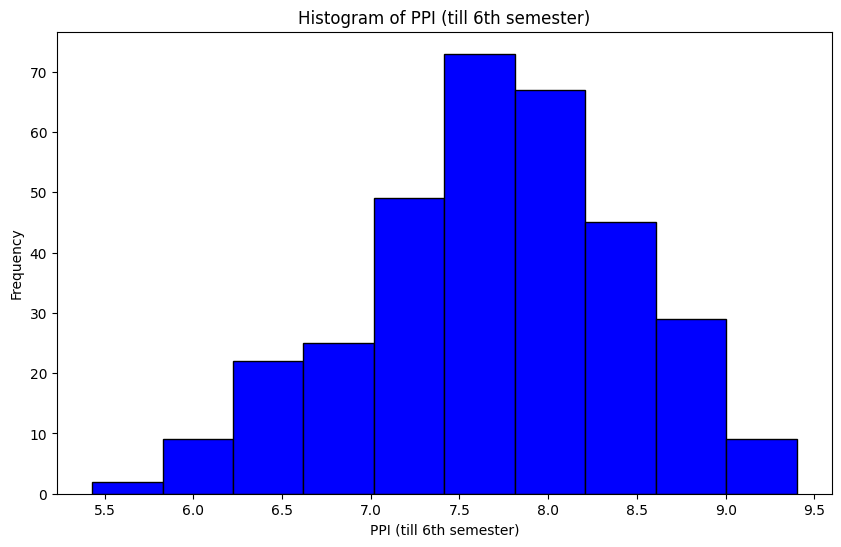

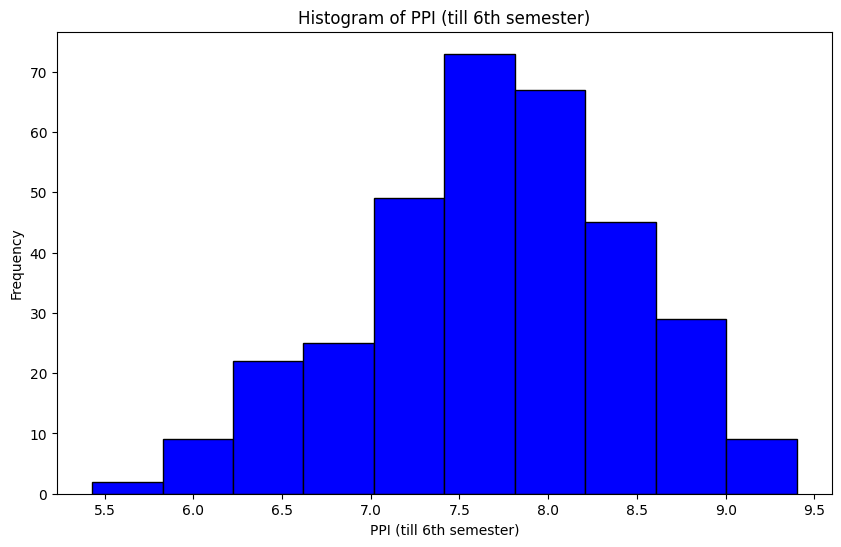

In [81]:
path='D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv'
message=f'''read csv on path ```{path}``` and plot histogram of column-"PPI (till 6th semester)" '''
with trace("My personal assistant-1"):
    result = await Runner.run(Boss_agent, message)

In [82]:
result

RunResult(input='read csv on path ```D:\\Sahib\\Learning is fun!\\GenAI\\Agentic AI\\Project-1\\cgpa.csv``` and plot histogram of column-"PPI (till 6th semester)" ', new_items=[MessageOutputItem(agent=Agent(name='Boss_Agent', handoff_description=None, tools=[FunctionTool(name='query_agent', description='Use this tool to generate good query to search. This tool returns queries that provide good results after searching', params_json_schema={'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'query_agent_args', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<function function_tool.<locals>._create_function_tool.<locals>._on_invoke_tool at 0x00000189F7B22160>, strict_json_schema=True, is_enabled=True), FunctionTool(name='search_on_arxiv', description="This Tool is used to search for some research paper on arxiv. It'll provide following info about papers:\nTitle\nAuthors\nPDF url\nPublication year\nCategories\nAbstract\n\nNote th

# **Test-3**
read csv on path ```<<path>>``` and perform stastistical analysis of column-"```<<column name>>```" using pandas

In [83]:
path='D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv'
message=f'''read csv on path ```{path}``` and perform stastistical analysis of column-"PPI (till 6th semester)" using pandas'''
with trace("My personal assistant-1"):
    result = await Runner.run(Boss_agent, message)

<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18580\1915636669.py:1: SyntaxWarning: invalid escape sequence '\S'
  path='D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv'


In [85]:
print(result.final_output)

The statistical analysis of the "PPI (till 6th semester)" column is as follows:

```
count    330.000000
mean       7.696667
std        0.756107
min        5.430000
25%        7.227500
50%        7.710000
75%        8.222500
max        9.400000
```

This analysis provides a summary of the central tendency, dispersion, and distribution of the PPI scores. Let me know if you'd like further insights or visualizations!


# **Test-4**
read csv on path ```<<path>>``` and analyze it

In [ ]:
path='D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv'
message=f'''read csv on path ```{path}``` and analyze it'''
with trace("My personal assistant-1"):
    result = await Runner.run(Boss_agent, message)

<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18580\795083501.py:1: SyntaxWarning: invalid escape sequence '\S'
  path='D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv'


In [92]:
print(result.final_output)

Here is the analysis of the CSV file:

**1. Data Preview:**
```
   Sr. No Student Roll Number                 Student Name  PPI (till 6th semester)                                      Project Title  Industry/Inhouse                   Industry Details/Project Details  Faculty Member
0     1.0            21BCE081  HALPATI SAHILKUMAR SOMABHAI   5.43  Spectral characterization of Marine debri, ISR...  Inhouse  Spectral characterization of Marine debri, ISR...   Dr Madhuri Bhavsar
1     2.0            22BCE501                  VISHAL ARYA   6.72  Spectral characterization of Marine debri, ISR...  Inhouse  Spectral characterization of Marine debri, ISR...   Dr Madhuri Bhavsar
2     3.0            21BCE327                  Yash Suthar   6.35  Hardware Development of AI/ML-based Object Det...  Inhouse  Hardware Development of AI/ML-based Object Det...   Dr Madhuri Bhavsar
3     4.0            21BCE001      AAKOLIYA HARSH KANTILAL   8.12  Reduction in backend API calling time for snow...   Ind

# **Test-5:** 
read csv on path ```<<given path>>``` and perform stastistical analysis of column-"```<<column name>>```" using pandas and send results to me on telegram.'

**Note:** it worked but hallucinated

<!-- 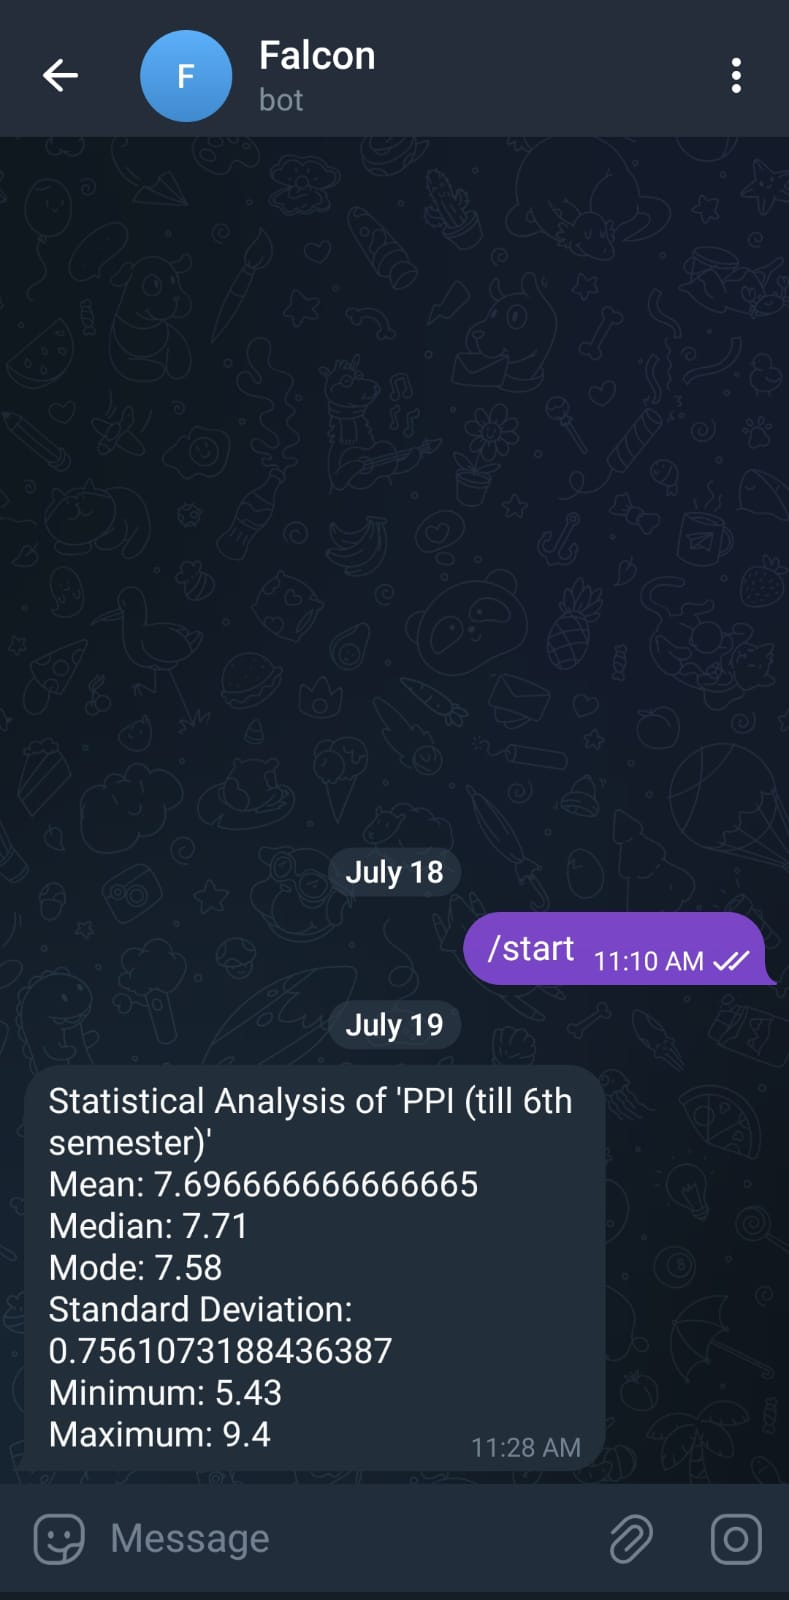 -->
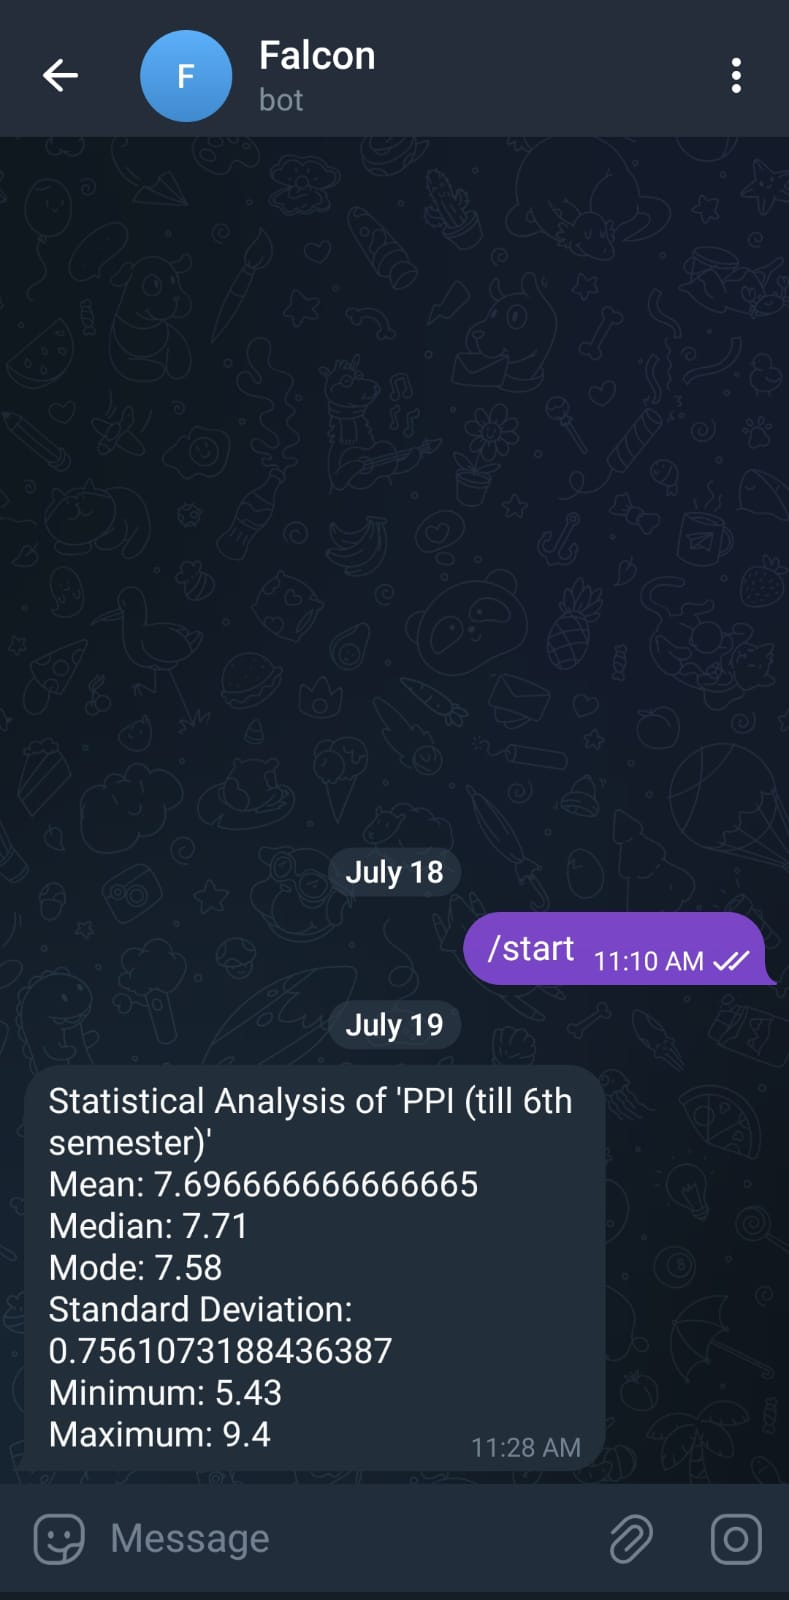

In [99]:
path='D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv'
message=f'''read csv on path ```{path}``` and perform stastistical analysis of column-"PPI (till 6th semester)" using pandas and send results 
to me on telegram.
'''
with trace("My personal assistant-1"):
    result = await Runner.run(Boss_agent, message)

<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18580\3176070537.py:1: SyntaxWarning: invalid escape sequence '\S'
  path='D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18580\3176070537.py:1: SyntaxWarning: invalid escape sequence '\S'
  path='D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv'


CancelledError: 

In [ ]:
path='D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv'
message=f'''read csv on path ```{path}``` and perform stastistical analysis of column-"PPI (till 6th semester)" using pandas and send results 
to me on telegram.
'''
with trace("My personal assistant-1"):
    result = await Runner.run(Boss_agent, message)

<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18580\3176070537.py:1: SyntaxWarning: invalid escape sequence '\S'
  path='D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18580\3176070537.py:1: SyntaxWarning: invalid escape sequence '\S'
  path='D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv'


CancelledError: 

In [ ]:
path='D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv'
message=f'''read csv on path ```{path}``` and perform stastistical analysis of column-"PPI (till 6th semester)" using pandas and send results 
to me on telegram.
'''
with trace("My personal assistant-1"):
    result = await Runner.run(Boss_agent, message)

<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18580\3176070537.py:1: SyntaxWarning: invalid escape sequence '\S'
  path='D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18580\3176070537.py:1: SyntaxWarning: invalid escape sequence '\S'
  path='D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv'


CancelledError: 

In [ ]:
path='D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv'
message=f'''read csv on path ```{path}``` and perform stastistical analysis of column-"PPI (till 6th semester)" using pandas and send results 
to me on telegram.
'''
with trace("My personal assistant-1"):
    result = await Runner.run(Boss_agent, message)

<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18580\3176070537.py:1: SyntaxWarning: invalid escape sequence '\S'
  path='D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18580\3176070537.py:1: SyntaxWarning: invalid escape sequence '\S'
  path='D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv'


CancelledError: 

In [97]:
result.final_output

'To assist you with reading the CSV file and performing statistical analysis on the "PPI (till 6th semester)" column, I will use the following tools:\n\n1. **run_code**: To execute a Python script that reads the CSV file and performs the statistical analysis.\n2. **Notify**: To send the results to you via Telegram.\n\nHere\'s the step-by-step plan:\n\n1. **Read the CSV file** using pandas.\n2. **Perform statistical analysis** on the "PPI (till 6th semester)" column.\n3. **Generate a summary** of the analysis.\n4. **Send the summary** to you via Telegram.\n\n### Tool Call 1: Run Code\n\n```python\nimport pandas as pd\n\n# Read the CSV file\ntry:\n    df = pd.read_csv(r"D:\\Sahib\\Learning is fun!\\GenAI\\Agentic AI\\Project-1\\cgpa.csv")\n    \n    # Perform statistical analysis on the "PPI (till 6th semester)" column\n    ppi_stats = df[\'PPI (till 6th semester)\'].describe()\n    \n    # Generate a formatted summary\n    summary = f"""\n    Statistical Analysis of PPI (till 6th semest